<center><img src="https://keras.io/img/logo-small.png" alt="Keras logo" width="100"><br/>
This starter notebook is provided by the Keras team.</center>

# Automated Essay Scoring 2.0 with [KerasNLP](https://github.com/keras-team/keras-nlp) and [Keras](https://github.com/keras-team/keras)

<div align="center">
    <img src="https://i.ibb.co/BrZf1MC/AESv2.jpg">
</div>

In this competition, our aim is to develop an AI model that can score student essays. This competition is actually an updated version of an old one that took place over a decade ago. In this version, we aim to improve upon essay scoring algorithms to enhance student learning outcomes. This notebook will guide you through the process of fine-tuning the **DebertaV3** model using **Ordinal Regression/Classification** to score student essays using KerasNLP.

**Did you know**: This notebook is backend-agnostic, which means it supports TensorFlow, PyTorch, and JAX backends. However, the best performance can be achieved with `JAX`. KerasNLP and Keras enable the choice of the preferred backend. Explore further details on [Keras](https://keras.io/keras_3/).

**Note**: For a deeper understanding of KerasNLP, refer to the [KerasNLP guides](https://keras.io/keras_nlp/).

# 📚 | Import Libraries

In [8]:
import os
os.environ["KERAS_BACKEND"] = "jax"  # "jax" or "tensorflow" or "torch"

import keras_nlp
import keras
import keras.backend as K
import tensorflow as tf

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = mpl.cm.get_cmap('coolwarm')

/tmp/ipykernel_4404/2827391943.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('coolwarm')


## Library Version

In [9]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasNLP:", keras_nlp.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
KerasNLP: 0.26.0


# ⚙️ | Configuration

In [10]:
class CFG:
    seed = 42  # Random seed
    preset = "deberta_v3_extra_small_en" # Name of pretrained models
    sequence_length = 512  # Input sequence length
    epochs = 3 # Training epochs
    batch_size = 32  # Batch size
    scheduler = 'cosine'  # Learning rate scheduler

# ♻️ | Reproducibility
Sets value for random seed to produce similar result in each run.

In [11]:
keras.utils.set_random_seed(CFG.seed)

# 🧮 | Mixed Precision

In [12]:
keras.mixed_precision.set_global_policy("mixed_float16")

# 📁 | Dataset Path

In [13]:
BASE_PATH = '/kaggle/input/learning-agency-lab-automated-essay-scoring-2'

# 📖 | Meta Data

**Files in the dataset:**

- `{test|train}.csv`
  - `essay_id`: Unique identifier for each essay.
  - `full_text`: Essay text.
  - `score`: Essay's score from `1-6`.
- `sample_submission.csv`: Valid sample submission.

**What does the `score` mean?**

The `score` represents the quality of student-written argumentative essays. Essays were rated based on a rubric covering perspective development, critical thinking, evidence use, organization, language, and grammar/mechanics. Here's a summary of the scoring criteria:

| Score | Description |
|-------|-------------|
| 6     | Clear mastery with few errors, outstanding critical thinking, appropriate evidence, well-organized, skilled language use. |
| 5     | Reasonable mastery with occasional errors, strong critical thinking, generally appropriate evidence, well-organized, good language use. |
| 4     | Adequate mastery with some lapses, competent critical thinking, adequate evidence, generally organized, fair language use. |
| 3     | Developing mastery with weaknesses, limited critical thinking, inconsistent evidence, limited organization, fair language use with weaknesses. |
| 2     | Little mastery with serious flaws, weak critical thinking, insufficient evidence, poor organization, limited language use with frequent errors. |
| 1     | Very little or no mastery, severely flawed, no viable point of view, disorganized, fundamental language flaws, pervasive grammar/mechanics errors. |

> This grading is very similar to the grading used in the [ETS GRE (Graduate Record Examinations) AWA](https://www.ets.org/gre/test-takers/general-test/prepare/content/analytical-writing.html) exam, where prospective graduate students are asked to write essays to judge their analytical abilities, and their scores are later used for graduate admission.


In [14]:
# Load data
df = pd.read_csv('train.csv')

# Display information about the train data
print("# Train Data: {:,}".format(len(df)))
print("# Sample:")
display(df.head(2))

# Train Data: 17,307
# Sample:


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3


# 🔪 | Data Split

In the code snippet provided below, we will divide the existing **train** data into folds using a stratification of `label` column.

In [15]:
from sklearn.model_selection import train_test_split  # Import package

train_df, valid_df = train_test_split(df, test_size=0.2, stratify=df["score"])

# 🧂 | Process Labels for Ordinal Regression

**What is Ordinal Regression?**
Ordinal regression is a type of supervised learning algorithm used to predict an ordinal or ranked dependent variable. Unlike in typical classification problems where the target variable is categorical, in ordinal regression the target variable has a ordering or ranking. It is also different from typical regression, where the target variable is continuous. In ordinal regression, the target variable has a discrete, ordered set of values, such as levels of satisfaction or performance grades.

**Why do we need it?**
Ordinal regression is useful when the target variable (in our competition, the `score` of an essay) represents a ranking or order. Specifically, ordinal regression can capture the inherent order in the target variable, which standard classification models may not be able to do effectively.

For Ordinal Regression, we have to transform the labels, which is different from typical classification or regression. The following code will convert essay scores to an ordinal matrix, which will be used as the ground truth for calculating the loss.

In [16]:
def to_ordinal(y, num_classes=None, dtype="float32"):
    """Converts a class vector (integers) to an ordinal regression matrix.

    This utility encodes class vector to ordinal regression/classification
    matrix where each sample is indicated by a row and rank of that sample is
    indicated by number of ones in that row.

    Args:
        y: Array-like with class values to be converted into a matrix
            (integers from 0 to `num_classes - 1`).
        num_classes: Total number of classes. If `None`, this would be inferred
            as `max(y) + 1`.
        dtype: The data type expected by the input. Default: `'float32'`.

    Returns:
        An ordinal regression matrix representation of the input as a NumPy
        array. The class axis is placed last.
    """
    y = np.array(y, dtype="int")
    input_shape = y.shape

    # Shrink the last dimension if the shape is (..., 1).
    if input_shape and input_shape[-1] == 1 and len(input_shape) > 1:
        input_shape = tuple(input_shape[:-1])

    y = y.reshape(-1)
    if not num_classes:
        num_classes = np.max(y) + 1
    n = y.shape[0]
    range_values = np.arange(num_classes - 1)
    range_values = np.tile(np.expand_dims(range_values, 0), [n, 1])
    ordinal = np.zeros((n, num_classes - 1), dtype=dtype)
    ordinal[range_values < np.expand_dims(y, -1)] = 1
    output_shape = input_shape + (num_classes - 1,)
    ordinal = np.reshape(ordinal, output_shape)
    return ordinal

In [17]:
scores = [1, 3, 5, 2, 6]

to_ordinal(scores)

array([[1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1.]], dtype=float32)

## Label Conversion

In [18]:
train_df["label"] = to_ordinal(train_df.score.values).tolist()
valid_df["label"] = to_ordinal(valid_df.score.values).tolist()

# 🎨 | EDA

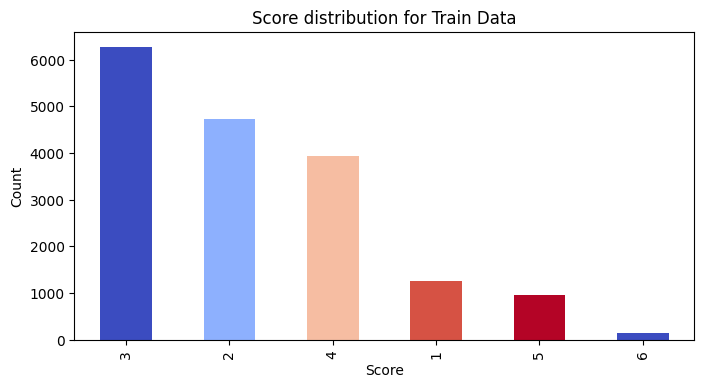

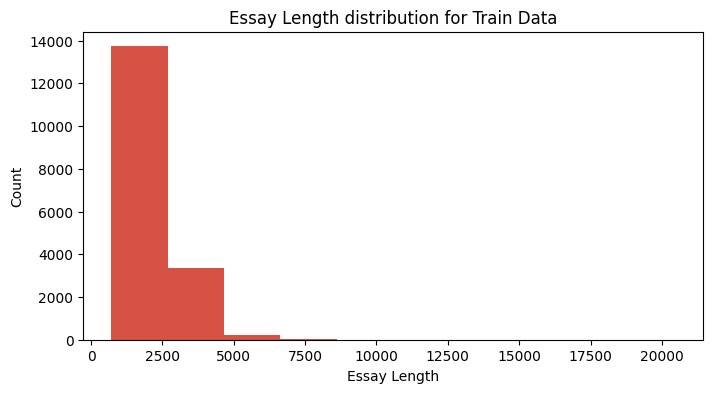

In [19]:
# Show distribution of answers using a bar plot
plt.figure(figsize=(8, 4))
df.score.value_counts().plot.bar(color=[cmap(0.0), cmap(0.25), cmap(0.65), cmap(0.9), cmap(1.0)])
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score distribution for Train Data")
plt.show()

# Show distribution of essay length using a bar plot
plt.figure(figsize=(8, 4))
df['essay_length'] = df.full_text.map(len)
df.essay_length.plot.hist(logy=False, color=cmap(0.9))
plt.xlabel("Essay Length")
plt.ylabel("Count")
plt.title("Essay Length distribution for Train Data")
plt.show()

# 🍽️ | Preprocessing

**What it does:** The preprocessor takes input strings and transforms them into a dictionary (`token_ids`, `padding_mask`) containing preprocessed tensors. This process starts with tokenization, where input strings are converted into sequences of token IDs.

**Why it's important:** Initially, raw text data is complex and challenging for modeling due to its high dimensionality. By converting text into a compact set of tokens, such as transforming `"The quick brown fox"` into `["the", "qu", "##ick", "br", "##own", "fox"]`, we simplify the data. Many models rely on special tokens and additional tensors to understand input. These tokens help divide input and identify padding, among other tasks. Making all sequences the same length through padding boosts computational efficiency, making subsequent steps smoother.

Explore the following pages to access the available preprocessing and tokenizer layers in **KerasNLP**:
- [Preprocessing](https://keras.io/api/keras_nlp/preprocessing_layers/)
- [Tokenizers](https://keras.io/api/keras_nlp/tokenizers/)

In [20]:
preprocessor = keras_nlp.models.DebertaV3Preprocessor.from_preset(
    preset=CFG.preset, # Name of the model
    sequence_length=CFG.sequence_length, # Max sequence length, will be padded if shorter
)

100%|██████████| 486/486 [00:00<00:00, 1.07MB/s]


100%|██████████| 614/614 [00:00<00:00, 1.26MB/s]


100%|██████████| 2.35M/2.35M [00:00<00:00, 10.4MB/s]


Now, let's examine what the output shape of the preprocessing layer looks like. The output shape of the layer can be represented as $(num\_choices, sequence\_length)$.

In [21]:
inp = preprocessor(df.full_text.iloc[0])  # Process text for the first row

# Display the shape of each processed output
for k, v in inp.items():
    print(k, ":", v.shape)

token_ids : (512,)
padding_mask : (512,)


We'll use the `preprocessing_fn` function to transform each text option using the `dataset.map(preprocessing_fn)` method.

In [22]:
def preprocess_fn(text, label=None):
    text = preprocessor(text)  # Preprocess text
    return (text, label) if label is not None else text  # Return processed text and label if available

# 🍚 | DataLoader

The code below sets up a robust data flow pipeline using `tf.data.Dataset` for data processing. Notable aspects of `tf.data` include its ability to simplify pipeline construction and represent components in sequences.

To learn more about `tf.data`, refer to this [documentation](https://www.tensorflow.org/guide/data).

In [23]:
def build_dataset(texts, labels=None, batch_size=32,
                  cache=True, drop_remainder=True,
                  shuffle=1024):
    AUTO = tf.data.AUTOTUNE  # AUTOTUNE option
    slices = (texts,) if labels is None else (texts, labels)  # Create slices
    ds = tf.data.Dataset.from_tensor_slices(slices)  # Create dataset from slices
    ds = ds.cache() if cache else ds  # Cache dataset if enabled
    ds = ds.map(preprocess_fn, num_parallel_calls=AUTO)  # Map preprocessing function
    opt = tf.data.Options()  # Create dataset options
    if shuffle:
        ds = ds.shuffle(shuffle, seed=CFG.seed)  # Shuffle dataset if enabled
        opt.experimental_deterministic = False
    ds = ds.with_options(opt)  # Set dataset options
    ds = ds.batch(batch_size, drop_remainder=drop_remainder)  # Batch dataset
    ds = ds.prefetch(AUTO)  # Prefetch next batch
    return ds

# ⚓ | LR Schedule

Implementing a learning rate scheduler is crucial for transfer learning. The learning rate initiates at `lr_start` and gradually tapers down to `lr_min` using various techniques, including:
- `step`: Lowering the learning rate in step-wise manner resembling stairs.
- `cos`: Utilizing a cosine curve to gradually reduce the learning rate.
- `exp`: Exponentially decreasing the learning rate.

**Importance:** A well-structured learning rate schedule is essential for efficient model training, ensuring optimal convergence and avoiding issues such as overshooting or stagnation.

In [24]:
import math

def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 0.6e-5, 0.3e-5 * batch_size, 0.3e-5
    lr_ramp_ep, lr_sus_ep, lr_decay = 2, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

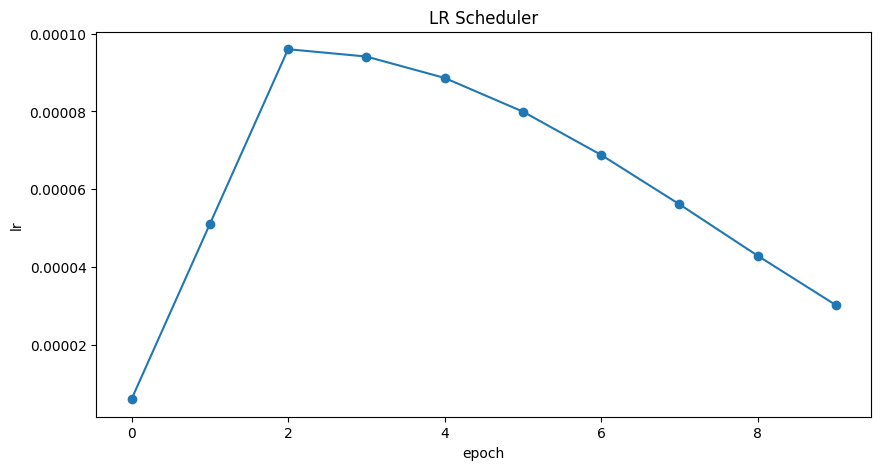

In [25]:
lr_cb = get_lr_callback(CFG.batch_size, plot=True)

# 💾 | Model Checkpointing

The following code will create a callback that will save the best checkpoint of the model during training, which we will use for inference in the submission.

In [26]:
ckpt_cb = keras.callbacks.ModelCheckpoint(
    "best_model.weights.h5",
    monitor="val_weighted_kappa",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
)


# 📏 | Metric

The metric for this competition is quadratic **Weighted Kappa**. This metric is particularly useful for tasks involving ordinal classification (where labels have inherent order). The following code implements this metric from scratch. This metric is implemented taking inspiration from [this TensorFlow implementation](https://www.tensorflow.org/addons/api_docs/python/tfa/losses/WeightedKappaLoss). You can learn more about this metric [here](https://www.sciencedirect.com/science/article/abs/pii/S0167865517301666).

> This metric implementation is a bit different than the competition metric, which was resolved by @taichiuemura in [here](https://www.kaggle.com/code/taichiuemura/aes-2-0-kerasnlp-starter/#%F0%9F%93%8F-%7C-Metric).

In [27]:
class WeightedKappa(keras.metrics.Metric):
    def __init__(self, num_classes=6, epsilon=1e-6):
        super().__init__(name="weighted_kappa")
        self.num_classes = num_classes
        self.epsilon = epsilon

        label_vec = keras.ops.arange(num_classes, dtype=keras.backend.floatx())
        self.row_label_vec = keras.ops.reshape(label_vec, [1, num_classes])
        self.col_label_vec = keras.ops.reshape(label_vec, [num_classes, 1])
        col_mat = keras.ops.tile(self.col_label_vec, [1, num_classes])
        row_mat = keras.ops.tile(self.row_label_vec, [num_classes, 1])
        self.weight_mat = (col_mat - row_mat) ** 2

        self.numerator = self.add_weight(name="numerator", initializer="zeros")
        self.denominator = self.add_weight(name="denominator", initializer="zeros")
        self.o_sum = self.add_weight(name="o_sum", initializer="zeros")
        self.e_sum = self.add_weight(name="e_sum", initializer="zeros")

    def update_state(self, y_true, y_pred, **args):
        # revert ordinal regression labels to classification labels
        y_true = keras.ops.one_hot(
            keras.ops.sum(keras.ops.cast(y_true, dtype="int8"), axis=-1) - 1, 6
        )
        y_pred = keras.ops.one_hot(
            keras.ops.sum(keras.ops.cast(y_pred > 0.5, dtype="int8"), axis=-1) - 1, 6
        )
        # weighted kappa calculation
        y_true = keras.ops.cast(y_true, dtype=self.col_label_vec.dtype)
        y_pred = keras.ops.cast(y_pred, dtype=self.weight_mat.dtype)
        batch_size = keras.ops.shape(y_true)[0]

        cat_labels = keras.ops.matmul(y_true, self.col_label_vec)
        cat_label_mat = keras.ops.tile(cat_labels, [1, self.num_classes])
        row_label_mat = keras.ops.tile(self.row_label_vec, [batch_size, 1])

        weight = (cat_label_mat - row_label_mat) ** 2

        self.numerator.assign_add(keras.ops.sum(weight * y_pred))
        label_dist = keras.ops.sum(y_true, axis=0, keepdims=True)
        pred_dist = keras.ops.sum(y_pred, axis=0, keepdims=True)
        w_pred_dist = keras.ops.matmul(
            self.weight_mat, keras.ops.transpose(pred_dist, [1, 0])
        )
        self.denominator.assign_add(
            keras.ops.sum(keras.ops.matmul(label_dist, w_pred_dist))
        )

        self.o_sum.assign_add(keras.ops.sum(y_pred))
        self.e_sum.assign_add(
            keras.ops.sum(
                keras.ops.matmul(keras.ops.transpose(label_dist, [1, 0]), pred_dist)
            )
        )

    def result(self):
        return 1.0 - (
            keras.ops.divide_no_nan(self.numerator, self.denominator)
            * keras.ops.divide_no_nan(self.e_sum, self.o_sum)
        )

    def reset_state(self):
        self.numerator.assign(0)
        self.denominator.assign(0)
        self.o_sum.assign(0)
        self.e_sum.assign(0)


# 🤖 | Modeling



## KerasNLP Classifier

The `KerasNLP` library provides comprehensive, ready-to-use implementations of popular NLP model architectures. It features a variety of pre-trained models including `Bert`, `Roberta`, `DebertaV3`, and more. In this notebook, we'll showcase the usage of `DebertaV3`. However, feel free to explore all available models in the [KerasNLP documentation](https://keras.io/api/keras_nlp/models/). Also, for a deeper understanding of `KerasNLP`, refer to the informative [getting started guide](https://keras.io/guides/keras_nlp/getting_started/).

Our approach involves using `keras_nlp.models.DebertaV3Classifier` to process each text and generate logits. These logits are passed through a `sigmoid` function to produce the final output.

> Note that we are tackling this problem as an **ordinal regression** problem, thus we have used `sigmoid` activation, but we can also consider this problem as a classification problem; then, we would've used `num_classes=6`, `softmax` activation, and `categorical_crossentropy` loss. We could even consider this as a **regression** problem with `num_classes=1`, `no activation` layer, and regression losses like MSE, MAE, etc. You are welcome to experiment with the typical classification and regression methods.

In [28]:
# Create a DebertaV3Classifier model
classifier = keras_nlp.models.DebertaV3Classifier.from_preset(
    CFG.preset, preprocessor=None, num_classes=6
)
inputs = classifier.input
logits = classifier(inputs)

# Compute final output
outputs = keras.layers.Activation("sigmoid")(logits)

# Build Model
model = keras.Model(inputs, outputs)

# Compile the model with optimizer, loss, and metrics
model.compile(
    optimizer=keras.optimizers.Adam(5e-6),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        WeightedKappa()
    ],
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deberta_v3_text_cl… │ (None, 6)         │ 70,832,262 │ padding_mask[0][… │
│ (DebertaV3TextClas… │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 6)         │          0 │ deberta_v3_text_… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,832,262 (270.20 MB)

 Trainable params: 70,832,262 (270.20 MB)

 Non-trainable params: 0 (0.00 B)

# 以下為自己的實驗

# Stratified K-Fold

In [29]:
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import keras_nlp
from sklearn.model_selection import StratifiedKFold

os.environ["KERAS_BACKEND"] = "tensorflow"

keras.utils.set_random_seed(CFG.seed)
keras.mixed_precision.set_global_policy("mixed_float16")

def build_dataset(texts, labels=None, batch_size=8, shuffle=False):
    slices = (texts,) if labels is None else (texts, labels)
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(preprocess_fn)
    ds = ds.batch(batch_size, drop_remainder=True)
    return ds

# ==========================================
# Stratified K-Fold 訓練（其餘設定與 Baseline 相同）
# ==========================================

df["label"] = to_ordinal(df.score.values).tolist()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)
oof_scores = []

# 5-Fold 交叉驗證
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["score"])):
    print(f"\n" + "="*20 + f" STARTING FOLD {fold + 1}/5 " + "="*20)

    # 清理記憶體，防止連續訓練時 OOM
    keras.backend.clear_session()
    gc.collect()

    preprocessor = keras_nlp.models.DebertaV3Preprocessor.from_preset(
        preset=CFG.preset,
        sequence_length=CFG.sequence_length,
    )

    def preprocess_fn(text, label=None):
        text = preprocessor(text)
        return (text, label) if label is not None else text

    # 根據當前 Fold 切分訓練集與驗證集
    fold_train_df = df.iloc[train_idx]
    fold_valid_df = df.iloc[val_idx]

    train_texts = fold_train_df.full_text.tolist()
    train_labels = np.array(fold_train_df.label.tolist())

    valid_texts = fold_valid_df.full_text.tolist()
    valid_labels = np.array(fold_valid_df.label.tolist())

    train_ds = build_dataset(
        train_texts, train_labels, batch_size=CFG.batch_size, shuffle=True
    )

    valid_ds = build_dataset(
        valid_texts, valid_labels, batch_size=CFG.batch_size, shuffle=False
    )

    classifier = keras_nlp.models.DebertaV3Classifier.from_preset(
        CFG.preset, preprocessor=None, num_classes=6
    )
    inputs = classifier.input
    logits = classifier(inputs)
    outputs = keras.layers.Activation("sigmoid")(logits)  # 序數回歸

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=5e-6),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            WeightedKappa()
        ],
    )

    lr_cb = get_lr_callback(CFG.batch_size, plot=False)

    # 儲存當前 Fold 的最佳模型權重
    ckpt_cb = keras.callbacks.ModelCheckpoint(
        f"best_model_fold_{fold + 1}.weights.h5",
        monitor="val_weighted_kappa",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
    )

    history = model.fit(
        train_ds,
        epochs=CFG.epochs,  # 依據最初設定的 3 輪進行公平比較
        validation_data=valid_ds,
        callbacks=[lr_cb, ckpt_cb]
    )

    # 記錄最佳的驗證 Weighted Kappa 分數
    best_fold_score = max(history.history['val_weighted_kappa'])
    oof_scores.append(best_fold_score)
    print(f"\n Fold {fold + 1} 訓練完成! 最佳 Validation Weighted Kappa: {best_fold_score:.4f}")


print("\n" + "="*20 + "  TRAINING SUMMARY " + "="*20)
for fold, score in enumerate(oof_scores):
    print(f">>>> Fold {fold + 1} Score: {score:.4f}")
print(f" 5-Fold 平均在地驗證分數 (Mean CV Score): {np.mean(oof_scores):.4f}")
print("="*50)





==================== STARTING FOLD 1/5 ====================


KeyboardInterrupt: 

## 以 prompt name 作為 Cross-Validation 切割數據的依據
在 Learning Agency Lab - Automated Essay Scoring 2.0 競賽中，官方資料集的 train.csv 確實沒有提供 prompt_id 或 prompt_name（題目名稱）。這份資料集其實是源自於公開資料集 PERSUADE。

在該競賽中，依據 Prompt（題目） 進行 GroupKFold 或是 StratifiedGroupKFold 數據切割，能更有效地模擬線上盲測（Hidden Test Set）對於新題目的泛化能力，避免模型過擬合（Overfitting）在特定題目的關鍵字上。

根據 Kaggle 討論區對於該資料集的文本分析，這次競賽的作文題目主要可以分為 7 大類（例如：無人車、金星探險、選舉、情緒識別、海之牛仔等）。我們可以使用 pandas 的 str.contains() 搭配關鍵字，自動加上 prompt_name 欄位。

因為要以 prompt_name 作為切割依據，同時又希望兼顧分數（score）的類別平衡，最完美的選擇是 StratifiedGroupKFold。這能確保：同一個題目的所有文章，只會同時出現在訓練集，或同時出現在驗證集。 每一折（Fold）裡，1~6 分的比例依然與原始資料維持平衡。

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import keras_nlp
from sklearn.model_selection import StratifiedGroupKFold

os.environ["KERAS_BACKEND"] = "tensorflow"

keras.utils.set_random_seed(CFG.seed)
keras.mixed_precision.set_global_policy("mixed_float16")

# ==========================================
# 加上 prompt_name def
# 根據文章的關鍵字，判斷這篇作文屬於哪個題目（共 7 種）。
# 這個資訊後續用來做分組切分，避免同題目的文章同時出現在訓練集和驗證集。
# ==========================================
def assign_prompt_name(text):
    text_lower = text.lower()
    if "driverless" in text_lower or "carless" in text_lower or "vauban" in text_lower:
        return "Driverless_Cars"
    elif "venus" in text_lower:
        return "Exploring_Venus"
    elif "mar" in text_lower or "face" in text_lower:
        return "Face_on_Mars"
    elif "electoral" in text_lower or "vote" in text_lower or "college" in text_lower:
        return "Electoral_College"
    elif "facial" in text_lower or "expression" in text_lower or "emotion" in text_lower:
        return "Facial_Emotion_Recognition"
    elif "cowboy" in text_lower or "seagoing" in text_lower:
        return "Seagoing_Cowboys"
    elif "car" in text_lower or "usage" in text_lower or "smog" in text_lower:
        return "Limiting_Car_Usage"
    else:
        return "Unknown_Prompt"

print(" 正在為原始資料加入 prompt_name 欄位...")
df["prompt_name"] = df["full_text"].apply(assign_prompt_name)

df["label"] = to_ordinal(df.score.values).tolist()

print(f" 題目分布統計：\n{df['prompt_name'].value_counts()}\n")

# ==========================================
# Stratified Group K-Fold
# ==========================================

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=CFG.seed)

oof_scores = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df["score"], groups=df["prompt_name"])):
    print(f"\n" + "="*20 + f" STARTING FOLD {fold + 1}/7 " + "="*20)

    val_prompts = df.iloc[val_idx]["prompt_name"].unique()
    print(f" 本折驗證集包含的題目: {val_prompts}")

    keras.backend.clear_session()
    gc.collect()

    preprocessor = keras_nlp.models.DebertaV3Preprocessor.from_preset(
        preset=CFG.preset,
        sequence_length=CFG.sequence_length,
    )

    def preprocess_fn(text, label=None):
        text = preprocessor(text)
        return (text, label) if label is not None else text

    fold_train_df = df.iloc[train_idx]
    fold_valid_df = df.iloc[val_idx]

    train_texts = fold_train_df.full_text.tolist()
    train_labels = np.array(fold_train_df.label.tolist())

    valid_texts = fold_valid_df.full_text.tolist()
    valid_labels = np.array(fold_valid_df.label.tolist())

    train_ds = build_dataset(
        train_texts, train_labels, batch_size=CFG.batch_size, shuffle=True
    )

    valid_ds = build_dataset(
        valid_texts, valid_labels, batch_size=CFG.batch_size, shuffle=False
    )

    classifier = keras_nlp.models.DebertaV3Classifier.from_preset(
        CFG.preset, preprocessor=None, num_classes=6
    )
    inputs = classifier.input
    logits = classifier(inputs)
    outputs = keras.layers.Activation("sigmoid")(logits)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=5e-6),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            WeightedKappa()
        ],
    )

    lr_cb = get_lr_callback(CFG.batch_size, plot=False)

    ckpt_cb = keras.callbacks.ModelCheckpoint(
        f"best_model_fold_{fold + 1}.weights.h5",
        monitor="val_weighted_kappa",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
    )

    history = model.fit(
        train_ds,
        epochs=CFG.epochs,
        validation_data=valid_ds,
        callbacks=[lr_cb, ckpt_cb]
    )

    best_fold_score = max(history.history['val_weighted_kappa'])
    oof_scores.append(best_fold_score)
    print(f"\n Fold {fold + 1} 訓練完成! 最佳 Validation Weighted Kappa: {best_fold_score:.4f}")

print("\n" + "="*20 + "  TRAINING SUMMARY " + "="*20)
for fold, score in enumerate(oof_scores):
    print(f">>>> Fold {fold + 1} Score: {score:.4f}")
print(f" 7-Fold 平均在地驗證分數 (Mean CV Score): {np.mean(oof_scores):.4f}")
print("="*50)

# pseudo_labeling

In [30]:
import pandas as pd

df = pd.read_parquet("pseudo_label.parquet")

print(df.head())
print(df.columns)
print(df.shape)

                                           full_text     score
0  Phones\n\nModern humans today are always on th...  3.181683
1  PHONES AND DRIVING\n\nIn this world in which w...  3.717352
2  explain if drivers should or should not be abl...  2.521436
3  Although cell phones have been around for quit...  4.192003
4  Simply because someone feels like they must re...  2.402955
Index(['full_text', 'score'], dtype='object')
(25996, 2)


In [31]:
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import keras_nlp
from sklearn.model_selection import StratifiedKFold  # 改用新資料的分折
from scipy.optimize import minimize                 # 用於尋找最佳閾值
from sklearn.metrics import cohen_kappa_score       # 用於計算標準 QWK

os.environ["KERAS_BACKEND"] = "tensorflow"

keras.utils.set_random_seed(CFG.seed)
keras.mixed_precision.set_global_policy("mixed_float16")

# ==========================================
# 1. 讀取資料：區分新資料與偽標籤舊資料
# ==========================================
# 這次比賽原本的官方訓練集
df_new = pd.read_csv("train.csv")

# 讀取 25,996 筆偽標籤舊資料
df_pseudo = pd.read_parquet("pseudo_label.parquet")

print(f"原始新資料量: {df_new.shape[0]}")
print(f"偽標籤舊資料量: {df_pseudo.shape[0]}")

# ==========================================
# 2. 定義優化 QWK 閾值的工具 (Nelder-Mead)
# ==========================================

def build_dataset(texts, labels=None, batch_size=8, shuffle=False, drop_remainder=False):
    slices = (texts,) if labels is None else (texts, labels)
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(preprocess_fn) # 移除 num_parallel_calls
    ds = ds.batch(batch_size, drop_remainder=drop_remainder)
    return ds

class OptimizedRounder:
    def __init__(self):
        self.coef_ = 0

    def _kappa_loss(self, coefficients, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coefficients[0]: X_p[i] = 1
            elif pred < coefficients[1]: X_p[i] = 2
            elif pred < coefficients[2]: X_p[i] = 3
            elif pred < coefficients[3]: X_p[i] = 4
            elif pred < coefficients[4]: X_p[i] = 5
            else: X_p[i] = 6
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def fit(self, X, y):
        loss_partial = lambda coefficients: self._kappa_loss(coefficients, X, y)
        initial_coefficients = [1.5, 2.5, 3.5, 4.5, 5.5]
        self.coef_ = minimize(loss_partial, initial_coefficients, method='Nelder-Mead')

    def predict(self, X, coefficients):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coefficients[0]: X_p[i] = 1
            elif pred < coefficients[1]: X_p[i] = 2
            elif pred < coefficients[2]: X_p[i] = 3
            elif pred < coefficients[3]: X_p[i] = 4
            elif pred < coefficients[4]: X_p[i] = 5
            else: X_p[i] = 6
        return X_p


# ==========================================
# 3. 5-Fold 交叉驗證 (僅針對新資料進行分折)
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)

oof_scores = []
best_thresholds_per_fold = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df_new, df_new["score"])):
    print(f"\n" + "="*20 + f" STARTING FOLD {fold + 1}/5 " + "="*20)

    keras.backend.clear_session()
    gc.collect()

    preprocessor = keras_nlp.models.DebertaV3Preprocessor.from_preset(
        preset=CFG.preset,
        sequence_length=CFG.sequence_length,
    )

    def preprocess_fn(text, label=None):
        text = preprocessor(text)
        return (text, label) if label is not None else text

    # 切分新資料的訓練與驗證
    fold_train_new_df = df_new.iloc[train_idx]
    fold_valid_df = df_new.iloc[val_idx]

    # 將全量偽標籤舊資料拼接到這一折的訓練集中
    # 這樣模型能吃到大量數據，但驗證集 (fold_valid_df) 依然保持純淨的新比賽標準
    combined_train_df = pd.concat([fold_train_new_df, df_pseudo], axis=0).sample(frac=1.0, random_state=CFG.seed).reset_index(drop=True)

    train_texts = combined_train_df.full_text.tolist()
    train_labels = combined_train_df.score.values.astype(np.float32)  # 保持浮點數

    valid_texts = fold_valid_df.full_text.tolist()
    valid_labels = fold_valid_df.score.values.astype(np.float32)

    train_ds = build_dataset(train_texts, train_labels, batch_size=CFG.batch_size, shuffle=True, drop_remainder=True)
    valid_ds = build_dataset(valid_texts, valid_labels, batch_size=CFG.batch_size, shuffle=False, drop_remainder=False)

    # ==========================================
    # 4. 建立迴歸模型 (Regression)
    # ==========================================
    # 將 num_classes 設為 1，連續數值預測
    classifier = keras_nlp.models.DebertaV3Classifier.from_preset(
        CFG.preset, preprocessor=None, num_classes=1
    )
    inputs = classifier.input
    logits = classifier(inputs)
    # 直接輸出線性連續值 (不加 Sigmoid 或 Softmax)
    outputs = keras.layers.Activation("linear", dtype="float32")(logits)

    model = keras.Model(inputs, outputs)

    # 使用 MSE (均方誤差) 作為迴歸的 Loss
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=5e-6, weight_decay=0.01),
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.RootMeanSquaredError()],
    )

    lr_cb = get_lr_callback(CFG.batch_size, plot=False)

    # 儲存最佳權重 (以驗證集 Loss 最低為準)
    ckpt_cb = keras.callbacks.ModelCheckpoint(
        f"best_model_fold_{fold + 1}.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
    )

    # 訓練
    history = model.fit(
        train_ds,
        epochs=CFG.epochs,
        validation_data=valid_ds,
        callbacks=[lr_cb, ckpt_cb]
    )

    # ==========================================
    # 5. 後處理：加載最佳模型並尋找動態閾值
    # ==========================================
    print(f"\n載入 Fold {fold + 1} 最佳權重以計算動態閾值...")
    model.load_weights(f"best_model_fold_{fold + 1}.weights.h5")

    # 預測驗證集 (浮點數)
    val_preds = model.predict(valid_ds).flatten()

    # 使用 Nelder-Mead 優化尋找該折最佳切分點
    optR = OptimizedRounder()
    optR.fit(val_preds, valid_labels)
    best_th = optR.coef_['x']
    best_thresholds_per_fold.append(best_th)

    # 用找到的閾值把預測值轉回 1~6 整數
    val_preds_int = optR.predict(val_preds, best_th)
    fold_qwk = cohen_kappa_score(valid_labels, val_preds_int, weights='quadratic')

    oof_scores.append(fold_qwk)
    print(f"Fold {fold + 1} 最佳切分閾值: {best_th}")
    print(f"Fold {fold + 1} Optimized QWK Score: {fold_qwk:.4f}")

# ==========================================
# 6. 總結
# ==========================================
print("\n" + "="*20 + " TRAINING SUMMARY " + "="*20)
for fold, score in enumerate(oof_scores):
    print(f">>>> Fold {fold + 1} QWK Score: {score:.4f}")
print(f" 5-Fold 平均在地驗證分數 (Mean CV QWK): {np.mean(oof_scores):.4f}")
# 輸出平均閾值
mean_thresholds = np.mean(best_thresholds_per_fold, axis=0)
print(f" 5-Fold 平均動態閾值 (用於測試集): {mean_thresholds}")
print("="*50)

原始新資料量: 17307
偽標籤舊資料量: 25996

==================== STARTING FOLD 1/5 ====================
Epoch 1/3
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 312s 209ms/step - loss: 0.8256 - root_mean_squared_error: 0.9086 - val_loss: 0.4422 - val_root_mean_squared_error: 0.6650 - learning_rate: 6.0000e-06
Epoch 2/3
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 231s 185ms/step - loss: 0.2369 - root_mean_squared_error: 0.4867 - val_loss: 0.4071 - val_root_mean_squared_error: 0.6380 - learning_rate: 5.1000e-05
Epoch 3/3
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 231s 185ms/step - loss: 0.1983 - root_mean_squared_error: 0.4453 - val_loss: 0.3895 - val_root_mean_squared_error: 0.6241 - learning_rate: 9.6000e-05

載入 Fold 1 最佳權重以計算動態閾值...
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 136ms/step
Fold 1 最佳切分閾值: [1.60545516 2.86269282 3.67082003 4.34274436 4.99563882]
Fold 1 Optimized QWK Score: 0.8082

==================== STARTING FOLD 2/5 ====================
Epoch 1/3
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 285s 202ms/step - loss: 0.7235 - root_mean_squared_error: 

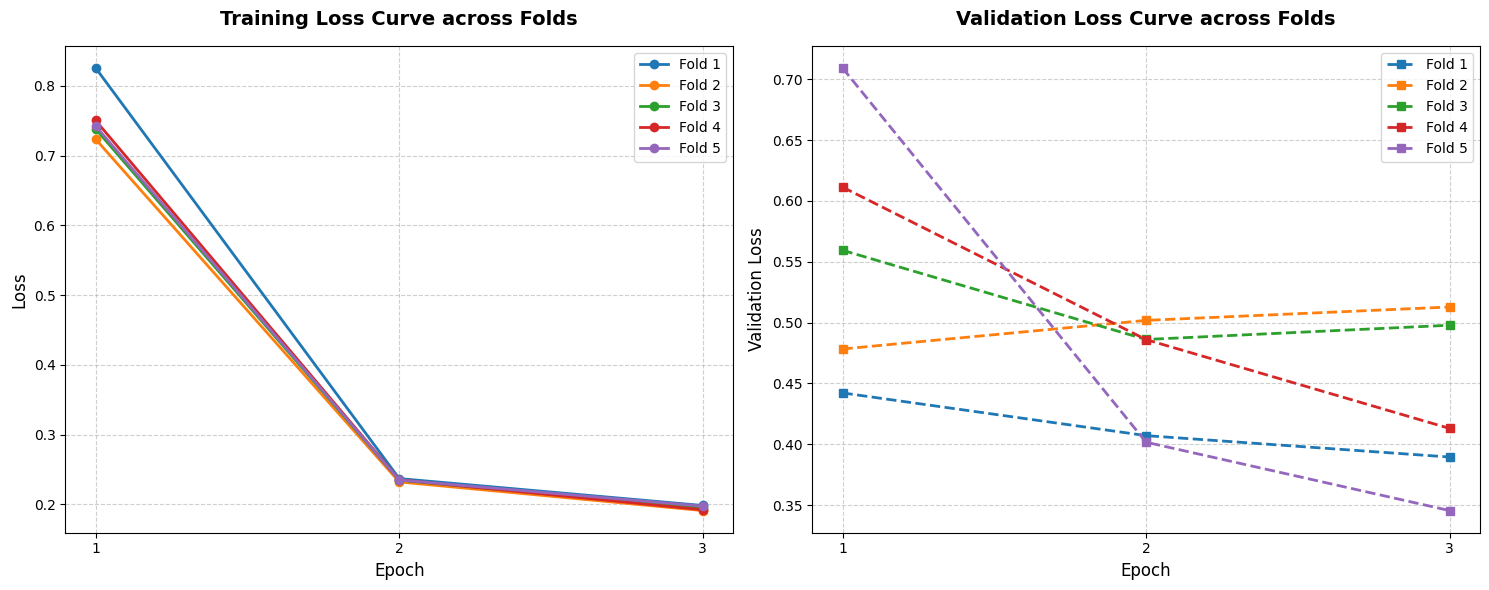

In [32]:
import matplotlib.pyplot as plt

# 1. 根據你的 log 截圖手動建立數據結構
fold_data = {
    "Fold 1": {
        "loss": [0.8256, 0.2369, 0.1983],
        "val_loss": [0.4422, 0.4071, 0.3895]
    },
    "Fold 2": {
        "loss": [0.7235, 0.2321, 0.1910],
        "val_loss": [0.4783, 0.5018, 0.5128]
    },
    "Fold 3": {
        "loss": [0.7381, 0.2346, 0.1946],
        "val_loss": [0.5594, 0.4861, 0.4978]
    },
    "Fold 4": {
        "loss": [0.7503, 0.2352, 0.1922],
        "val_loss": [0.6113, 0.4860, 0.4130]
    },
    "Fold 5": {
        "loss": [0.7424, 0.2349, 0.1974],
        "val_loss": [0.7092, 0.4017, 0.3455]
    }
}

epochs = [1, 2, 3]

# 2. 設定畫布，左邊放 Training Loss，右邊放 Validation Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 定義每個 Fold 的顏色，方便對照
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 3. 繪製 Training Loss
for i, (fold_name, metrics) in enumerate(fold_data.items()):
    ax1.plot(epochs, metrics["loss"], marker='o', color=colors[i], linewidth=2, label=f'{fold_name}')

ax1.set_title('Training Loss Curve across Folds', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)

# 4. 繪製 Validation Loss
for i, (fold_name, metrics) in enumerate(fold_data.items()):
    ax2.plot(epochs, metrics["val_loss"], marker='s', linestyle='--', color=colors[i], linewidth=2, label=f'{fold_name}')

ax2.set_title('Validation Loss Curve across Folds', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Loss', fontsize=12)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=10)

# 調整佈局並顯示
plt.tight_layout()
plt.show()